In [1]:
# importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import shap;

/home/vcollares/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Carregando o dataSet
df = pd.read_parquet('dadosMinas/bdqueimadas_final.parquet')

In [ ]:
# Criando dataframe apenas com dados do Cerrado
df_cerrado = df[df['Bioma'] == 'Cerrado'].copy()

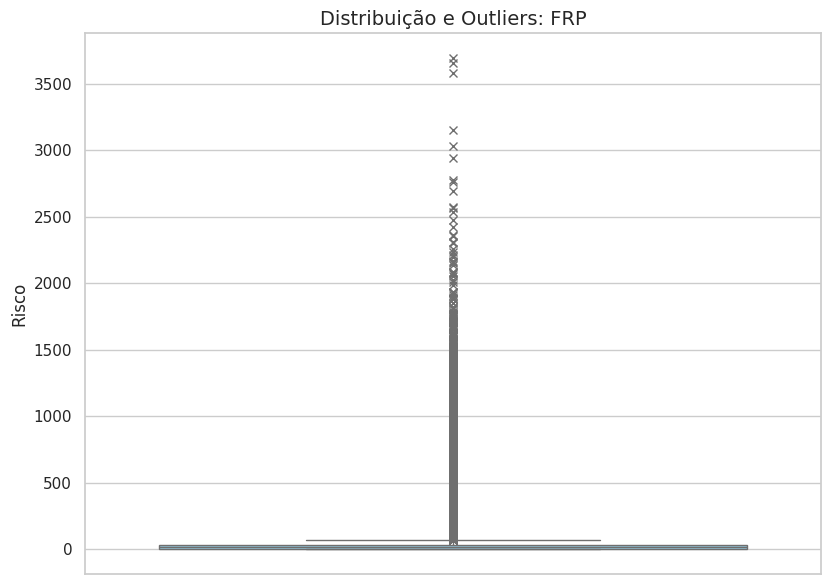

In [7]:
# Gráfico de outliers dos foco do modelo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_cerrado['FRP'], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})
plt.title('Distribuição e Outliers: FRP', fontsize=14)
plt.ylabel('Risco', fontsize=12)


plt.tight_layout()
plt.show()

In [8]:
df_cerrado.describe()

,DataHora,DiaSemChuva,Precipitacao,RiscoFogo,FRP,Latitude,Longitude,Temperatura_C,Umidade_Relativa_%,Vento_ms
count,1310222,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06,1.310222e+06
mean,2019-05-27 00:24:46.797770496,3.176171e+01,3.598839e-01,9.143049e-01,2.888556e+01,-1.795371e+01,-4.566510e+01,2.762655e+01,3.878953e+01,2.621711e+00
min,2006-01-02 13:12:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.161404e+01,-5.087214e+01,2.795563e+00,2.865255e+00,5.988311e-03
25%,2015-09-25 16:43:00,5.000000e+00,0.000000e+00,9.888621e-01,6.300000e+00,-1.942301e+01,-4.685500e+01,2.326309e+01,2.589787e+01,1.860369e+00
50%,2020-09-20 16:18:00,1.500000e+01,0.000000e+00,1.000000e+00,1.710000e+01,-1.800116e+01,-4.569443e+01,2.831143e+01,3.554800e+01,2.497899e+00
75%,2023-08-24 04:17:00,4.933804e+01,5.609280e-02,1.000000e+00,3.305915e+01,-1.658060e+01,-4.427311e+01,3.217935e+01,4.874241e+01,3.343781e+00
max,2026-03-31 05:01:00,8.360000e+02,9.200000e+01,1.046191e+00,3.694800e+03,-1.423600e+01,-4.177667e+01,4.193399e+01,1.000092e+02,8.961655e+00
std,NaN,3.674962e+01,1.991195e+00,2.211029e-01,5.182283e+01,1.683444e+00,1.740646e+00,5.843818e+00,1.673114e+01,1.101510e+00


In [27]:
# Contando as fatias de intensidade do FRP
qtd_zero = len(df_cerrado[df_cerrado['FRP'] == 0])
qtd_menor_10 = len(df_cerrado[(df_cerrado['FRP'] > 0) & (df_cerrado['FRP'] < 10)])
qtd_maior_10 = len(df_cerrado[df_cerrado['FRP'] >= 10])
qtd_maior_500 = len(df_cerrado[df_cerrado['FRP'] >= 500])
total = len(df_cerrado)

print("FRP NO CERRADO:")
print(f"Sem fogo (FRP = 0)         : {qtd_zero:,.0f} registros ({(qtd_zero/total)*100:.2f}%)")
print(f"Fogo pequeno (0 < FRP < 10): {qtd_menor_10:,.0f} registros ({(qtd_menor_10/total)*100:.2f}%)")
print(f"Fogo intenso (FRP >= 10)   : {qtd_maior_10:,.0f} registros ({(qtd_maior_10/total)*100:.2f}%)")
print(f"Fogo intenso (FRP >= 500)   : {qtd_maior_500:,.0f} registros ({(qtd_maior_500/total)*100:.2f}%)")
print("-" * 60)
print(f" Total de registros na base    : {total:,.0f}")

FRP NO CERRADO:
Sem fogo (FRP = 0)         : 128 registros (0.01%)
Fogo pequeno (0 < FRP < 10): 468,693 registros (35.77%)
Fogo intenso (FRP >= 10)   : 841,401 registros (64.22%)
Fogo intenso (FRP >= 500)   : 2,115 registros (0.16%)
------------------------------------------------------------
 Total de registros na base    : 1,310,222


In [37]:
from sklearn.model_selection import RandomizedSearchCV

X_treino_grid = X_treino_r.sample(frac=0.2, random_state=42)
y_treino_grid = y_treino_r.loc[X_treino_grid.index]

xgb_base = XGBRegressor(
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

param_dist = {
    'n_estimators': [300, 400, 500, 600, 700],        
    'max_depth': [6, 8, 10, 12],                 
    'learning_rate': [0.01, 0.05, 0.1],          
    'subsample': [0.7, 0.85, 1.0],              
    'colsample_bytree': [0.7, 0.85, 1.0],        
    'min_child_weight': [1, 3, 5, 7],            
    'gamma': [0, 0.5, 1, 5],                    
    'reg_alpha': [0, 0.1, 1],                    
    'reg_lambda': [1, 5, 10, 20]                 
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50, 
    scoring='neg_mean_absolute_error',
    cv=3,       
    verbose=2,  
    random_state=42,
    n_jobs=1 
)

random_search.fit(X_treino_grid, y_treino_grid)

for param, valor in random_search.best_params_.items():
    if isinstance(valor, str):
        print(f"    {param}='{valor}',")
    else:
        print(f"    {param}={valor},")

melhor_erro = -random_search.best_score_
print(f"\nErro Médio Simulado (MAE) na Validação: {melhor_erro:.2f} MW")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.7, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=7, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   8.6s
[CV] END colsample_bytree=0.7, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=7, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0.5, learning_rate=0.1, max_depth=8, min_child_weight=7, n_estimators=600, reg_alpha=1, reg_lambda=5, subsample=0.7; total time=   2.8s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=600, reg_alpha=1, reg_lambda=10, subsample=1.0; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=600, reg_alpha=1, reg_lambda=10, subsample=1.0; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=8, 

In [38]:
print("PARÂMETROS VENCEDORES:")
for param, valor in random_search.best_params_.items():
    print(f"{param} = {valor},")

PARÂMETROS VENCEDORES:
subsample = 1.0,
reg_lambda = 5,
reg_alpha = 0.1,
n_estimators = 700,
min_child_weight = 5,
max_depth = 12,
learning_rate = 0.1,
gamma = 0,
colsample_bytree = 0.85,


Resultado FRP
 - Erro Médio Absoluto (MAE): 6.64 MW
 - Score R² (Explicação)    : 0.6896


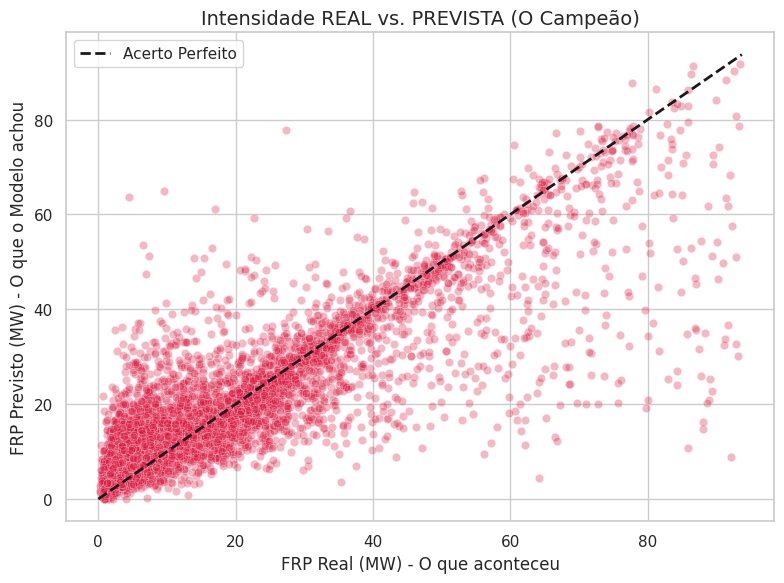

In [41]:
df_frp = df_cerrado.copy()

df_frp['DataHora'] = pd.to_datetime(df_frp['DataHora'])
df_frp['Mes'] = df_frp['DataHora'].dt.month
df_frp['Hora'] = df_frp['DataHora'].dt.hour

limite_superior = df_frp['FRP'].quantile(0.95)
df_frp_limpo = df_frp[df_frp['FRP'] <= limite_superior]

X = df_frp_limpo[['DiaSemChuva', 'Precipitacao', 'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms', 'Mes', 'Hora', 'Latitude', 'Longitude']]
y = df_frp_limpo['FRP']
X_treino_r, X_teste_r, y_treino_r, y_teste_r = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_xgb_reg = XGBRegressor(
    subsample = 1.0,
    reg_lambda = 5,
    reg_alpha = 0.1,
    n_estimators = 700,
    min_child_weight = 5,
    max_depth = 12,
    learning_rate = 0.1,
    gamma = 0,
    colsample_bytree = 0.85,
    tree_method = 'hist', 
    n_jobs = -1,          
    random_state = 42    
)



modelo_xgb_reg.fit(X_treino_r, y_treino_r)

previsoes_frp = modelo_xgb_reg.predict(X_teste_r)

previsoes_frp = np.clip(previsoes_frp, a_min=0, a_max=None)

erro_medio = mean_absolute_error(y_teste_r, previsoes_frp)
r2 = r2_score(y_teste_r, previsoes_frp)

print(f"Resultado FRP")
print(f" - Erro Médio Absoluto (MAE): {erro_medio:.2f} MW")
print(f" - Score R² (Explicação)    : {r2:.4f}")


plt.figure(figsize=(8, 6))
amostra_idx = np.random.choice(len(y_teste_r), size=min(5000, len(y_teste_r)), replace=False)
sns.scatterplot(x=y_teste_r.iloc[amostra_idx], y=previsoes_frp[amostra_idx], alpha=0.3, color='crimson')
plt.plot([0, limite_superior], [0, limite_superior], 'k--', lw=2, label='Acerto Perfeito')
plt.title('Intensidade REAL vs. PREVISTA (O Campeão)', fontsize=14)
plt.xlabel('FRP Real (MW) - O que aconteceu', fontsize=12)
plt.ylabel('FRP Previsto (MW) - O que o Modelo achou', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


Gráfico 1: O que mais aumenta a FORÇA do incêndio no Cerrado? (Importância Global)


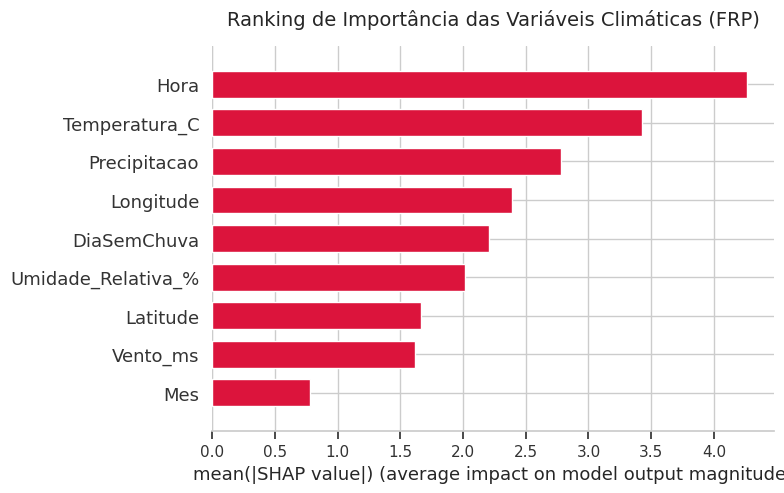


Gráfico 2: Como o clima afeta a intensidade? (Vermelho vs Azul)


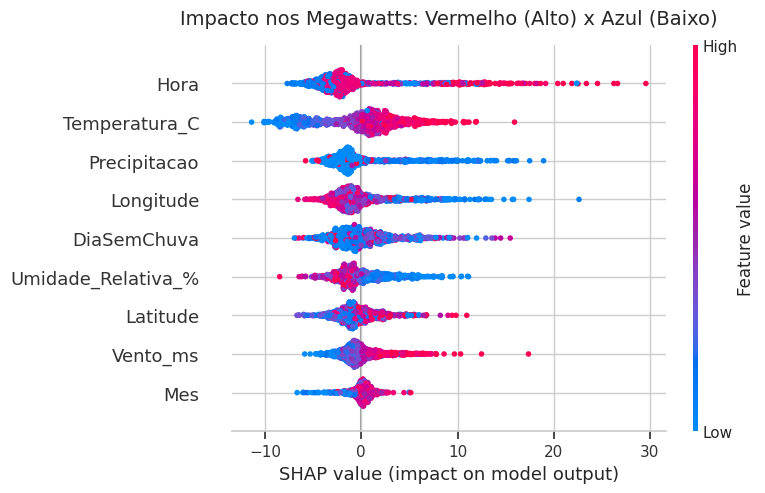

 A variável número 1 para definir a força do fogo foi: **Hora**
 Em segundo lugar: **Temperatura_C**


In [43]:
X_amostra_shap = X_teste_r.sample(n=1000, random_state=42)

explainer = shap.TreeExplainer(modelo_xgb_reg)
valores_shap = explainer.shap_values(X_amostra_shap)

print("\nGráfico 1: O que mais aumenta a FORÇA do incêndio no Cerrado? (Importância Global)")
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, X_amostra_shap, plot_type="bar", show=False, color="crimson")
plt.title("Ranking de Importância das Variáveis Climáticas (FRP)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\nGráfico 2: Como o clima afeta a intensidade? (Vermelho vs Azul)")
plt.figure(figsize=(10, 6))
shap.summary_plot(valores_shap, X_amostra_shap, show=False)
plt.title("Impacto nos Megawatts: Vermelho (Alto) x Azul (Baixo)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

importancia_media = np.abs(valores_shap).mean(axis=0)
indices_top_2 = np.argsort(importancia_media)[-2:][::-1]
variaveis_top_2 = X_amostra_shap.columns[indices_top_2].tolist()

print(f" A variável número 1 para definir a força do fogo foi: **{variaveis_top_2[0]}**")
print(f" Em segundo lugar: **{variaveis_top_2[1]}**")

In [44]:
import joblib
joblib.dump(modelo_xgb_reg, 'regressor_intensidade_frp.pkl')

['regressor_intensidade_frp.pkl']